In [1]:
pip install "numpy<2.0,>=1.24.0"

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'D:\Project\Waste Classification\WasteClassification\imageclassification\Scripts\python.exe -m pip install --upgrade pip' command.


In [2]:
import tensorflow as tf
print(tf.__version__)

2.10.0


In [3]:
pip install opencv-python matplotlib

  Using cached numpy-2.2.6-cp310-cp310-win_amd64.whl (12.9 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'D:\\Project\\Waste Classification\\WasteClassification\\imageclassification\\Lib\\site-packages\\~4mpy.libs\\libopenblas64__v0.3.23-293-gc2f4bdbb-gcc_10_3_0-2bde3a66a51006b2b53eb373ff767a3f.dll'
Check the permissions.

You should consider upgrading via the 'D:\Project\Waste Classification\WasteClassification\imageclassification\Scripts\python.exe -m pip install --upgrade pip' command.


In [4]:
!pip list

Package                      Version
---------------------------- -----------
absl-py                      2.3.1
asttokens                    3.0.0
astunparse                   1.6.3
blinker                      1.9.0
cachetools                   5.5.2
certifi                      2025.8.3
charset-normalizer           3.4.3
click                        8.2.1
colorama                     0.4.6
comm                         0.2.3
contourpy                    1.3.2
cycler                       0.12.1
debugpy                      1.8.16
decorator                    5.2.1
exceptiongroup               1.3.0
executing                    2.2.0
Flask                        3.1.2
flatbuffers                  25.2.10
fonttools                    4.60.1
gast                         0.4.0
google-auth                  2.40.3
google-auth-oauthlib         0.4.6
google-pasta                 0.2.0
grpcio                       1.74.0
h5py                         3.14.0
idna                         3.10
ip

You should consider upgrading via the 'D:\Project\Waste Classification\WasteClassification\imageclassification\Scripts\python.exe -m pip install --upgrade pip' command.


In [5]:
import tensorflow as tf
import os

In [6]:
# Avoid OOM errors by setting GPU Memory Consumption Growth
gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus: 
    tf.config.experimental.set_memory_growth(gpu, True)

In [7]:
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [8]:
import tensorflow as tf

# Check available physical devices
gpus = tf.config.list_physical_devices('GPU')
print("GPUs detected:", gpus)

# Quick test
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))
print("Built with CUDA:", tf.test.is_built_with_cuda())
print("GPU Available (legacy check):", tf.test.is_gpu_available(cuda_only=False, min_cuda_compute_capability=None))


GPUs detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Num GPUs Available: 1
Built with CUDA: True
Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.
GPU Available (legacy check): True


In [9]:
from tensorflow.python.client import device_lib

# List all local devices
devices = device_lib.list_local_devices()
for d in devices:
    if d.device_type == 'GPU':
        print(d.physical_device_desc)


device: 0, name: NVIDIA GeForce RTX 3050 6GB Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


In [10]:
import cv2
import imghdr

In [11]:
data_dir = 'data1' 

In [12]:
image_exts = ['jpeg','jpg', 'bmp', 'png']

In [13]:
for image_class in os.listdir(data_dir): 
    for image in os.listdir(os.path.join(data_dir, image_class)):
        image_path = os.path.join(data_dir, image_class, image)
        try: 
            img = cv2.imread(image_path)
            tip = imghdr.what(image_path)
            if tip not in image_exts: 
                print('Image not in ext list {}'.format(image_path))
                os.remove(image_path)
        except Exception as e: 
            print('Issue with image {}'.format(image_path))
            # os.remove(image_path)

In [14]:
import numpy as np
from matplotlib import pyplot as plt

In [15]:
data = tf.keras.utils.image_dataset_from_directory('data1')

Found 15515 files belonging to 12 classes.


In [16]:
data

<BatchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [17]:
data_iterator = data.as_numpy_iterator()

In [18]:
batch = data_iterator.next()

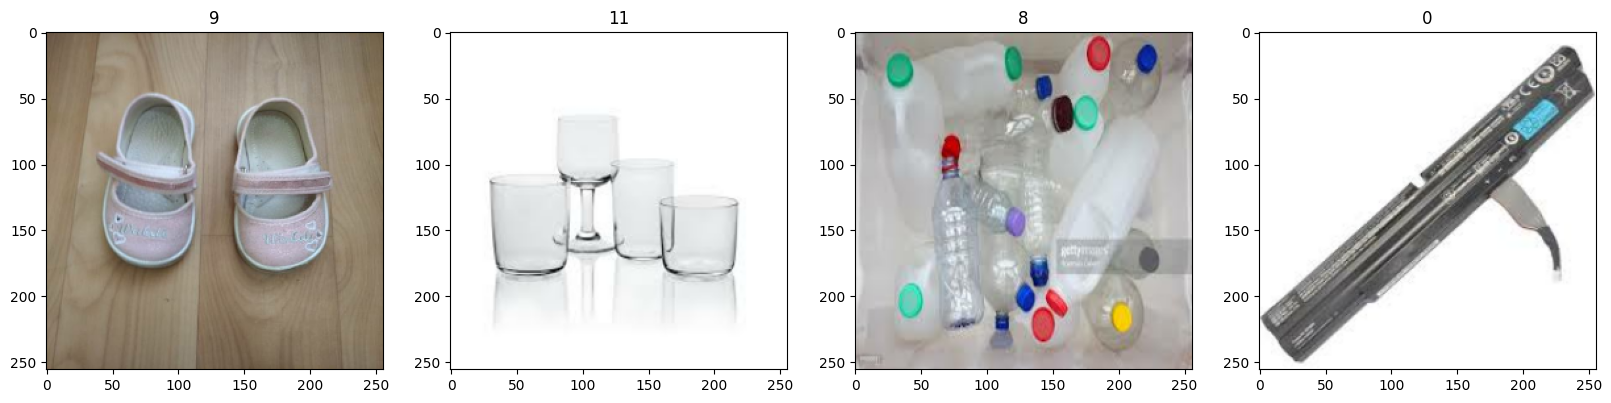

In [19]:
fig, ax = plt.subplots(ncols=4, figsize=(20,20))
for idx, img in enumerate(batch[0][:4]):
    ax[idx].imshow(img.astype(int))
    ax[idx].title.set_text(batch[1][idx])

In [20]:
data = data.map(lambda x,y: (x/255, y))

In [21]:
scaled_iterator = data.as_numpy_iterator()

In [22]:
batch = scaled_iterator.next()

In [23]:
batch[0].min()

0.0

In [24]:
batch[0].max()

1.0

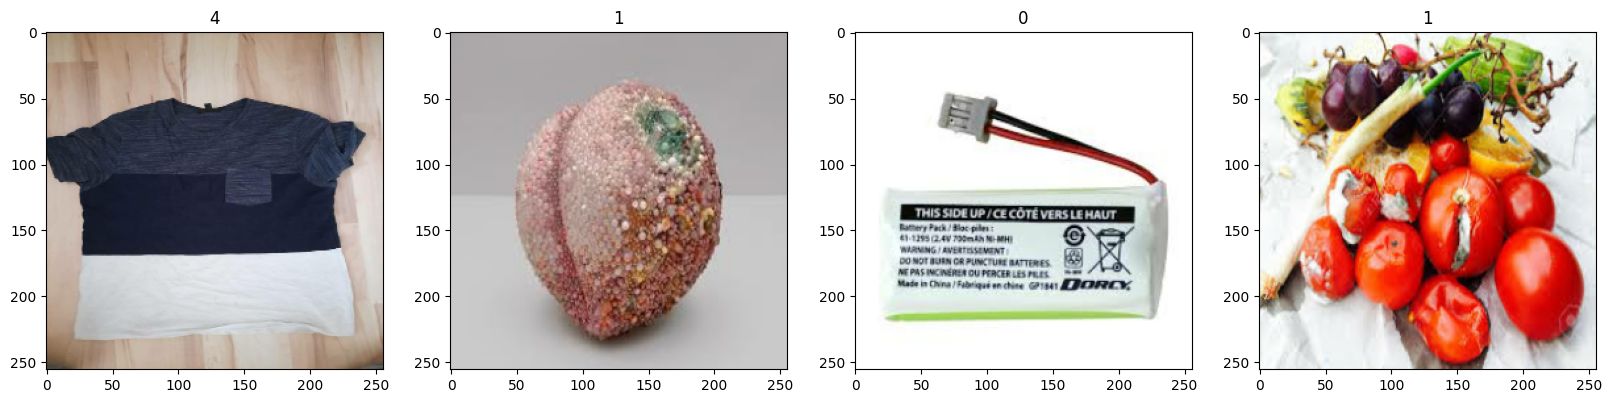

In [25]:
fig, ax = plt.subplots(ncols=4, figsize=(20,20))
for idx, img in enumerate(batch[0][:4]):
    ax[idx].imshow(img)
    ax[idx].title.set_text(batch[1][idx])

In [26]:
train_size = int(len(data)*.7)
val_size = int(len(data)*.2)
test_size = int(len(data)*.1)

In [27]:
train = data.take(train_size)
val = data.skip(train_size).take(val_size)
test = data.skip(train_size+val_size).take(test_size)

In [28]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization

In [29]:
model = Sequential()

In [30]:
num_classes = 12

In [40]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, optimizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import tensorflow.keras.backend as K

# Enhanced residual block with squeeze-and-excitation
def residual_block_se(x, filters, kernel_size=3, stride=1, se_ratio=16):
    """
    Residual block with Squeeze-and-Excitation attention mechanism
    """
    shortcut = x
    
    # Main path
    x = layers.Conv2D(filters, kernel_size, strides=stride, padding="same",
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    
    x = layers.Conv2D(filters, kernel_size, padding="same",
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    
    # Squeeze-and-Excitation for attention mechanism
    if se_ratio:
        # Squeeze: Global average pooling
        se = layers.GlobalAveragePooling2D()(x)
        # Excitation: Two fully connected layers
        se = layers.Dense(max(filters // se_ratio, 4), activation='relu')(se)  # Ensure minimum 4 units
        se = layers.Dense(filters, activation='sigmoid')(se)
        se = layers.Reshape((1, 1, filters))(se)
        # Scale the features
        x = layers.multiply([x, se])
    
    # Projection shortcut if dimensions don't match
    if shortcut.shape[-1] != filters or stride != 1:
        shortcut = layers.Conv2D(filters, 1, strides=stride, padding="same",
                                kernel_regularizer=regularizers.l2(1e-4))(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)
    
    # Add skip connection
    x = layers.add([x, shortcut])
    x = layers.ReLU()(x)
    return x

# Regular residual block (without SE) for comparison
def residual_block(x, filters, kernel_size=3, stride=1):
    """
    Standard residual block without attention
    """
    shortcut = x
    
    # First conv layer
    x = layers.Conv2D(filters, kernel_size, strides=stride, padding="same",
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # Second conv layer
    x = layers.Conv2D(filters, kernel_size, padding="same",
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)

    # Projection shortcut if dimensions don't match
    if shortcut.shape[-1] != filters or stride != 1:
        shortcut = layers.Conv2D(filters, 1, strides=stride, padding="same",
                                kernel_regularizer=regularizers.l2(1e-4))(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    # Add skip connection
    x = layers.add([x, shortcut])
    x = layers.ReLU()(x)
    return x

# Build Advanced ResNet with SE blocks
def build_advanced_resnet(input_shape, num_classes, use_se=True):
    """
    Build advanced ResNet with optional Squeeze-and-Excitation blocks
    """
    inputs = layers.Input(shape=input_shape)
    
    # Enhanced initial layers
    x = layers.Conv2D(64, 7, strides=2, padding="same")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D(3, strides=2, padding="same")(x)
    
    # Choose which residual block to use
    res_block = residual_block_se if use_se else residual_block
    
    # Block 1: 64 filters, 3 blocks
    for _ in range(3):
        x = res_block(x, 64)
    
    # Block 2: 128 filters, 3 blocks (with downsampling in first block)
    x = res_block(x, 128, stride=2)
    for _ in range(2):
        x = res_block(x, 128)
    
    # Block 3: 256 filters, 5 blocks (with downsampling in first block)
    x = res_block(x, 256, stride=2)
    for _ in range(4):
        x = res_block(x, 256)
    
    # Block 4: 512 filters, 2 blocks (with downsampling in first block)
    x = res_block(x, 512, stride=2)
    for _ in range(1):
        x = res_block(x, 512)
    
    # Enhanced classification head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    
    model = models.Model(inputs, outputs, name="Advanced_ResNet_SE" if use_se else "Advanced_ResNet")
    return model

# Create and compile the model - FIXED VERSION
def create_and_compile_model(model_type='advanced_se', input_shape=(256, 256, 3), num_classes=10):
    """
    Create and compile the selected model type - FIXED
    """
    if model_type == 'advanced_se':
        model = build_advanced_resnet(input_shape, num_classes, use_se=True)
    elif model_type == 'advanced':
        model = build_advanced_resnet(input_shape, num_classes, use_se=False)
    elif model_type == 'deeper':
        model = build_deeper_resnet(input_shape, num_classes)
    else:
        raise ValueError("model_type should be 'advanced_se', 'advanced', or 'deeper'")
    
    # FIXED: Use simple learning rate first, add scheduling via callbacks
    optimizer = optimizers.Adam(learning_rate=1e-3)
    
    # Compile model
    model.compile(
        optimizer=optimizer,
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
        metrics=['accuracy']
    )
    
    return model

# Deeper ResNet function (was missing)
def build_deeper_resnet(input_shape, num_classes):
    """
    Deeper ResNet with more layers (ResNet34 style)
    """
    inputs = layers.Input(shape=input_shape)
    
    # Initial layers
    x = layers.Conv2D(64, 7, strides=2, padding="same")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D(3, strides=2, padding="same")(x)
    
    # ResNet34-like architecture
    # Block 1: 3 residual blocks with 64 filters
    for _ in range(3):
        x = residual_block(x, 64)
    
    # Block 2: 4 residual blocks with 128 filters
    x = residual_block(x, 128, stride=2)
    for _ in range(3):
        x = residual_block(x, 128)
    
    # Block 3: 6 residual blocks with 256 filters
    x = residual_block(x, 256, stride=2)
    for _ in range(5):
        x = residual_block(x, 256)
    
    # Block 4: 3 residual blocks with 512 filters
    x = residual_block(x, 512, stride=2)
    for _ in range(2):
        x = residual_block(x, 512)
    
    # Classification head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    
    model = models.Model(inputs, outputs, name="Deeper_ResNet")
    return model

# Enhanced callbacks
def get_callbacks(model_name="best_model"):
    """
    Get training callbacks
    """
    return [
        EarlyStopping(
            monitor='val_accuracy',
            patience=15,
            restore_best_weights=True,
            mode='max'
        ),
        ModelCheckpoint(
            f"{model_name}.h5",
            monitor='val_accuracy',
            save_best_only=True,
            mode='max',
            save_weights_only=False
        ),
        ReduceLROnPlateau(
            monitor='val_accuracy',
            factor=0.5,
            patience=5,
            min_lr=1e-7,
            mode='max'
        )
    ]

# Main execution
if __name__ == "__main__":
    # Configuration
    input_shape = (256, 256, 3)
    num_classes = 12  
    
    # Create model (choose one: 'advanced_se', 'advanced', 'deeper')
    model = create_and_compile_model(
        model_type='advanced_se',  # Best for accuracy
        input_shape=input_shape,
        num_classes=num_classes
    )
    
    # Display model architecture
    model.summary()

Model: "Advanced_ResNet_SE"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_5 (InputLayer)           [(None, 256, 256, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d_95 (Conv2D)             (None, 128, 128, 64  9472        ['input_5[0][0]']                
                                )                                                                 
                                                                                                  
 batch_normalization_98 (BatchN  (None, 128, 128, 64  256        ['conv2d_95[0][0]']              
 ormalization)                  )                                                

In [64]:
# Print model type
print(f"\nModel created: {model.name}")
print("Features:")
print("- Squeeze-and-Excitation Attention" if 'SE' in model.name else "- Standard Residual Blocks")
print("- Advanced Architecture with Multiple Blocks")
print("- Enhanced Classification Head")
print("- L2 Regularization")
print("- Batch Normalization")
    
# Callbacks
callbacks = get_callbacks(f"best_{model.name}")
    
print("\nCallbacks configured:")
print("- Early Stopping (patience=15)")
print("- Model Checkpoint")
print("- ReduceLROnPlateau")
    
    # Training example (uncomment when ready)
  
    # Assuming you have train, val datasets
history = model.fit(
    train,
    epochs=50,
    validation_data=val,
    callbacks=callbacks,
    verbose=1
)
    
# Evaluate
test_loss, test_acc = model.evaluate(test)
print(f"Test Accuracy ({model.name}): {test_acc:.4f}")
  
    
print("\nModel is ready for training!")
print("Uncomment the training section and provide your datasets to start training.")


Model created: Advanced_ResNet_SE
Features:
- Squeeze-and-Excitation Attention
- Advanced Architecture with Multiple Blocks
- Enhanced Classification Head
- L2 Regularization
- Batch Normalization

Callbacks configured:
- Early Stopping (patience=15)
- Model Checkpoint
- ReduceLROnPlateau
Epoch 1/50
339/339 [==============================] - 199s 581ms/step - loss: 0.1396 - accuracy: 0.9996 - val_loss: 0.7861 - val_accuracy: 0.8837 - lr: 4.8828e-07
Epoch 2/50
339/339 [==============================] - 163s 477ms/step - loss: 0.1398 - accuracy: 0.9995 - val_loss: 0.7875 - val_accuracy: 0.8834 - lr: 4.8828e-07
Epoch 3/50
339/339 [==============================] - 166s 486ms/step - loss: 0.1404 - accuracy: 0.9994 - val_loss: 0.7712 - val_accuracy: 0.8850 - lr: 4.8828e-07
Epoch 4/50
339/339 [==============================] - 162s 477ms/step - loss: 0.1402 - accuracy: 0.9991 - val_loss: 0.7825 - val_accuracy: 0.8860 - lr: 4.8828e-07
Epoch 5/50
339/339 [==============================] - 159

KeyboardInterrupt: 

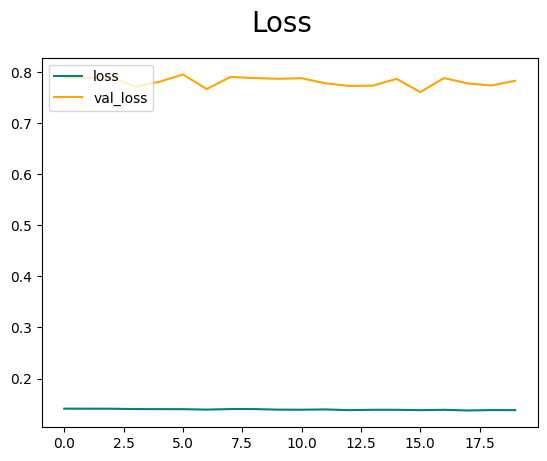

In [65]:
fig = plt.figure()
plt.plot(history.history['loss'], color='teal', label='loss')
plt.plot(history.history['val_loss'], color='orange', label='val_loss')
fig.suptitle('Loss', fontsize=20)
plt.legend(loc="upper left")
plt.show()

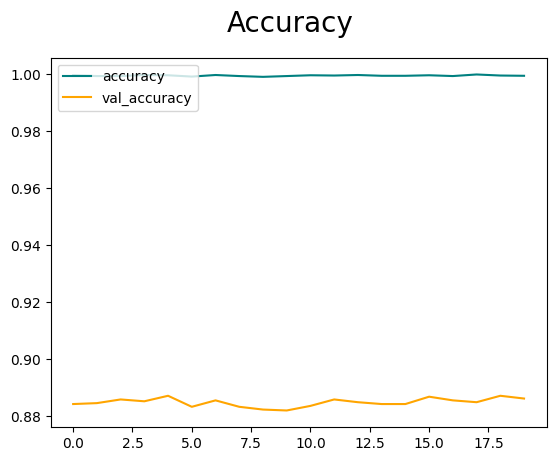

In [66]:
fig = plt.figure()
plt.plot(history.history['accuracy'], color='teal', label='accuracy')
plt.plot(history.history['val_accuracy'], color='orange', label='val_accuracy')
fig.suptitle('Accuracy', fontsize=20)
plt.legend(loc="upper left")
plt.show()

In [45]:
!pip install scikit-learn

You should consider upgrading via the 'D:\Project\Waste Classification\WasteClassification\imageclassification\Scripts\python.exe -m pip install --upgrade pip' command.


In [46]:
!pip install seaborn

You should consider upgrading via the 'D:\Project\Waste Classification\WasteClassification\imageclassification\Scripts\python.exe -m pip install --upgrade pip' command.


1/1 [==============================] - 0s 106ms/step
              precision    recall  f1-score   support

   cardboard       0.89      0.77      0.82       103
     clothes       0.78      0.94      0.86        88
       glass       0.86      0.84      0.85        64
 green-glass       0.86      0.92      0.89        90
       metal       0.95      0.97      0.96       523
       paper       0.91      0.89      0.90        66
     plastic       0.77      0.69      0.73        91
       shoes       0.90      0.86      0.88       105
       trash       0.71      0.79      0.75        73
 white-glass       0.82      0.80      0.81       184
         bio       0.83      0.80      0.82        66
     battery       0.78      0.67      0.72        83

    accuracy                           0.87      1536
   macro avg       0.84      0.83      0.83      1536
weighted avg       0.87      0.87      0.87      1536



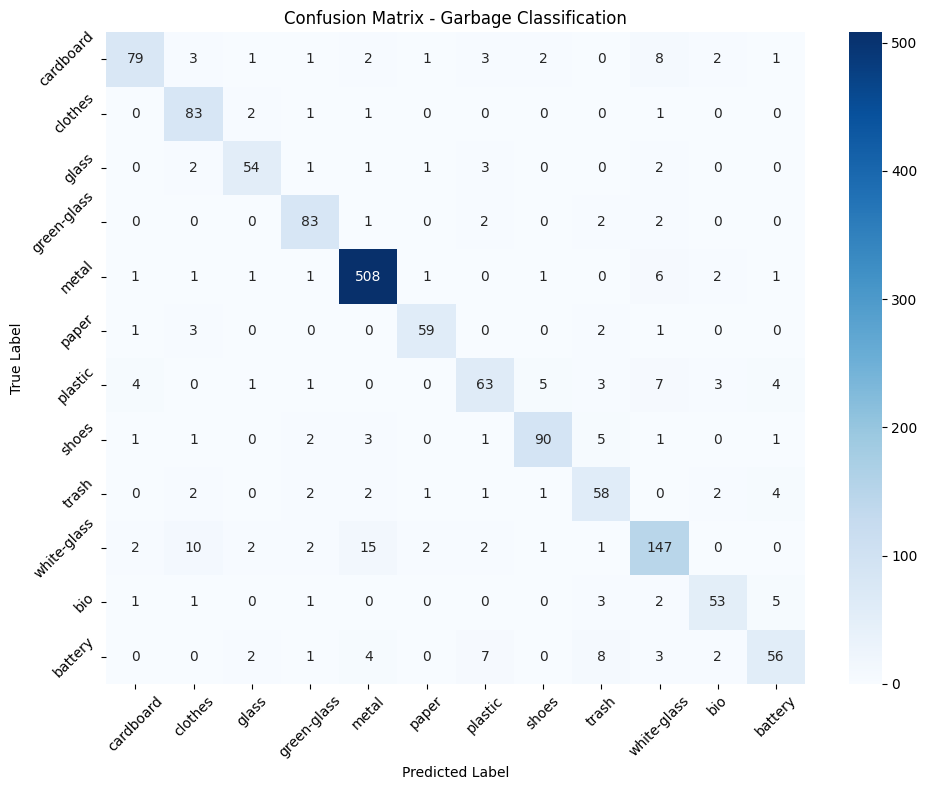

In [67]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Store true and predicted labels
y_true = []
y_pred = []

# Iterate through test dataset
for X, y in test.as_numpy_iterator():
    # Get predictions
    yhat = model.predict(X)
    
    # Append true labels (convert tensor to numpy if needed)
    y_true.extend(y)
    
    # Append predicted labels
    y_pred.extend(np.argmax(yhat, axis=1))

# ✅ Class names for 12-class garbage dataset
class_names = [
    'cardboard', 'clothes', 'glass', 'green-glass', 
    'metal', 'paper', 'plastic', 'shoes', 
    'trash', 'white-glass', 'bio', 'battery'
]

# Classification Report
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=class_names, yticklabels=class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Garbage Classification")
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
plt.show()


In [68]:
from tensorflow.keras.metrics import SparseCategoricalAccuracy

acc = SparseCategoricalAccuracy()
for batch in test.as_numpy_iterator(): 
    X, y = batch
    yhat = model.predict(X)
    acc.update_state(y, yhat)

print("Test Accuracy:", acc.result().numpy())


1/1 [==============================] - 0s 103ms/step
Test Accuracy: 0.8613281


In [69]:
import cv2

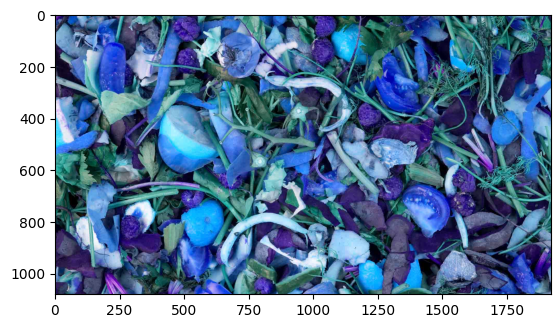

In [70]:
img = cv2.imread('154006829.jpg')
plt.imshow(img)
plt.show()

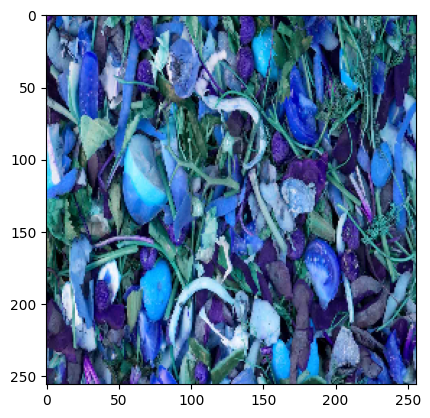

In [71]:
resize = tf.image.resize(img, (256,256))
plt.imshow(resize.numpy().astype(int))
plt.show()

In [72]:
yhat = model.predict(np.expand_dims(resize/255, 0))

1/1 [==============================] - 0s 148ms/step


In [73]:
yhat

array([[7.6669298e-02, 1.8293329e-04, 5.8614147e-05, 2.7704003e-04,
        2.6030757e-02, 1.5992775e-04, 4.0489319e-03, 5.8685970e-01,
        3.0546436e-01, 1.7403647e-05, 7.3378091e-05, 1.5761518e-04]],
      dtype=float32)

In [74]:
import numpy as np

# yhat is the softmax output from your model
pred_class_index = np.argmax(yhat, axis=-1)  # get the index of the highest probability

# Map index to class name
class_names = ['battery', 'biological', 'brown-glass', 'cardboard', 'clothes', 'green-glass','metal','paper','plastic','shoes','trash','white-glass']
pred_class_name = class_names[pred_class_index[0]]  # [0] if single sample

print(f'Predicted class is {pred_class_name}')


Predicted class is paper


In [75]:
from tensorflow.keras.models import load_model

In [76]:
model.save(os.path.join('models','imageclassifier.h5'))

In [77]:
new_model = load_model('models/imageclassifier.h5')